# Semana 5 — Representación de texto: del bag-of-words a los embeddings

En este notebook recorremos la evolución de cómo representamos texto numéricamente para que un modelo de ML lo pueda procesar:

1. **Parte 1 — Representaciones clásicas** (`CountVectorizer`, `TF-IDF`): vectores dispersos basados en conteos de palabras, con aplicaciones a clasificación supervisada y clustering no supervisado.
2. **Parte 2 — Tokenización por subpalabras (BPE)**: el algoritmo que usan GPT, BERT, Claude y demás modelos modernos para dividir el texto.
3. **Parte 3 — Embeddings densos**: vectores que sí capturan significado semántico, producidos por redes neuronales pre-entrenadas.

---

## Parte 1: Representaciones clásicas de texto

### 1.1 Cargar el corpus de noticias políticas

Empezamos con un corpus de ~500 noticias políticas colombianas. Cada fila tiene `content` (texto), `date`, `headline` y `description`.

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import numpy as np
import pandas as pd
import nltk

df = pd.read_csv("../datasets/noticias_sample.csv").dropna()
df.iloc[3, 0]

'Este lunes, de cara a una semana clave para la reforma a la salud en el Congreso de la República, David Racero, presidente de la Cámara de Representantes, habló sobre las expectativas de la bancada de Gobierno en torno a la iniciativa. De acuerdo con el congresista, esta lograría aprobarse en primer debate entre el miércoles y el jueves. “Se ha venido tejiendo de manera muy cuidadosa el acuerdo final respecto al proyecto de salud definitivo. Esperamos que esta semana se apruebe la ponencia positiva y el articulado. Es decir, en dos semanas estaríamos aprobando la reforma a la salud en la plenaria de la Cámara”, manifestó el presidente de esa corporación. La idea, según Racero, es lograr los acuerdos con los partidos para la aprobación de la reforma en la Comisión Séptima de la Cámara de Representantes. De esta forma, se facilitará la aprobación en los próximos debates. “Así que estamos en el momento de mayor tensión, de mayor diálogo en los puntos más neurálgicos, pero seguimos con el

In [2]:
df

,content,date,headline,description
0,"Esta semana, el Senado y la Cámara de Represen...",2022-11-10T18:42:14.884Z,"“Con algunas excepciones, un abusivo es un pas...",El senador del Pacto Histórico se refirió al c...
1,"Hace pocas horas, el expresidente interino de ...",2023-04-24T13:58:31.866Z,Gustavo Bolívar se pronunció sobre visita a Co...,El expresidente interino de Venezuela llegará ...
2,En medio de la preocupación que han elevado va...,2023-03-24T14:53:30.902Z,“Recibimos el país inundado en coca”: fuerte s...,El funcionario diplomático del Gobierno del pr...
3,"Este lunes, de cara a una semana clave para la...",2023-04-24T20:03:25.019Z,“Esperamos que entre miércoles y jueves se ten...,El presidente de la Cámara de Representantes e...
4,"Sin duda, el presidente Gustavo Petro, el mini...",2023-03-24T02:57:29.758Z,"Tras fracaso de la reforma política, Gobierno ...",Aunque esa decisión se pudo tomar desde el sem...
...,...,...,...,...
495,Más de 50 representantes del sector emprendedo...,2022-10-19T00:18:36.429Z,“Nos toca irnos del país para seguir subsistie...,Los voceros de pequeñas y medianas empresas as...
496,"Gilberto Tobón Sanín, excandidato al Senado de...",2022-11-30T05:02:30.124Z,"“No le hago mandados a nadie, soy autónomo”: G...",El aspirante afirmó que su “compromiso es con ...
497,Las diferencias entre el senador de la bancada...,2022-11-30T15:18:07.075Z,Gustavo Bolívar arremete en contra del senador...,"El ministro de Hacienda, presente en el debate..."
498,"En la tarde de este jueves, 24 de noviembre, e...",2022-11-25T04:26:26.611Z,"El ministro del Interior, Alfonso Prada, fue d...",Con el Puerto Pisisí esperan mover 1. 630.000 ...


### 1.2 CountVectorizer: el vectorizador más simple

`CountVectorizer` divide cada texto en palabras (y n-gramas) y cuenta cuántas veces aparece cada una. El resultado es una matriz `(n_documentos × n_tokens)` muy dispersa.

A continuación lo entrenamos con n-gramas de 1 a 3 palabras, sin filtrar nada. Veremos las 10 palabras más frecuentes.

In [3]:
# Inicializar el CountVectorizer
vectorizer_count = CountVectorizer(ngram_range=(1,3))

# Entrenar el CountVectorizer y transformar los textos
articles_embeddings = vectorizer_count.fit_transform(df['content']).toarray()

# Extraer el vocabulario y las frecuencias correspondientes
vocabulary = vectorizer_count.get_feature_names_out()
frequencies = articles_embeddings.sum(axis=0).ravel()

# Ordenar los tokens por frecuencia de mayor a menor
sorted_indices = frequencies.argsort()[::-1]

# Mostrar los tokens más frecuentes junto con sus frecuencias
for idx in sorted_indices[0:10]:
    print(f"{vocabulary[idx]}: {frequencies[idx]}")

de: 26521
la: 18648
que: 16888
el: 14592
en: 12087
los: 6466
se: 6030
del: 5917
las: 5102
no: 5048


In [4]:
len(vocabulary)

483100

In [5]:
articles_embeddings.shape

(492, 483100)

El vocabulario tiene cientos de miles de tokens — la mayoría aparecen muy pocas veces y no aportan información útil. Limitemos el vocabulario a los 2000 tokens más frecuentes:

In [6]:
# Inicializar el CountVectorizer
vectorizer_count = CountVectorizer(max_features=2000, ngram_range=(1,3))

# Entrenar el CountVectorizer y transformar los textos
articles_embeddings = vectorizer_count.fit_transform(df['content']).toarray()

# Extraer el vocabulario y las frecuencias correspondientes
vocabulary = vectorizer_count.get_feature_names_out()

len(vocabulary)

2000

In [7]:
articles_embeddings.shape

(492, 2000)

### 1.3 Removiendo stopwords

Las palabras más frecuentes ('de', 'la', 'que', 'el', ...) son **stopwords**: palabras funcionales que aparecen en cualquier texto y no aportan información para distinguir un documento de otro. NLTK trae listas de stopwords para muchos idiomas:

In [8]:
# Descargar las stopwords en español de NLTK (si no se han descargado)
spanish_stopwords = nltk.corpus.stopwords.words('spanish')

spanish_stopwords[0:20]

['de',
 'la',
 'que',
 'el',
 'en',
 'y',
 'a',
 'los',
 'del',
 'se',
 'las',
 'por',
 'un',
 'para',
 'con',
 'no',
 'una',
 'su',
 'al',
 'lo']

In [9]:
len(spanish_stopwords)

313

Reentrenamos `CountVectorizer` excluyendo las stopwords. Ahora las palabras más frecuentes deberían ser temáticas (políticos, instituciones, temas):

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import numpy as np
import pandas as pd
import nltk

df = pd.read_csv("../datasets/noticias_sample.csv").dropna()

# Descargar las stopwords en español de NLTK (si no se han descargado)
spanish_stopwords = nltk.corpus.stopwords.words('spanish')

# Inicializar el CountVectorizer
vectorizer_count = CountVectorizer(max_features=2000, stop_words=spanish_stopwords, ngram_range=(1,3))

# Entrenar el CountVectorizer y transformar los textos
articles_embeddings = vectorizer_count.fit_transform(df['content']).toarray()

# Extraer el vocabulario y las frecuencias correspondientes
vocabulary = vectorizer_count.get_feature_names_out()
frequencies = articles_embeddings.sum(axis=0).ravel()

# Ordenar los tokens por frecuencia de mayor a menor
sorted_indices = frequencies.argsort()[::-1]

# Mostrar los tokens más frecuentes junto con sus frecuencias
for idx in sorted_indices[0:10]:
    print(f"{vocabulary[idx]}: {frequencies[idx]}")

petro: 1786
gobierno: 1760
presidente: 1573
semana: 994
país: 936
colombia: 904
gustavo: 896
si: 885
gustavo petro: 778
dijo: 741


Ahora con n-gramas de **solo 2-3 palabras** (sin unigramas) — para ver bigramas y trigramas frecuentes que capturan ideas/entidades compuestas:

In [11]:
# Inicializar el CountVectorizer
vectorizer_count = CountVectorizer(max_features=2000, stop_words=spanish_stopwords, ngram_range=(2,3))

# Entrenar el CountVectorizer y transformar los textos
articles_embeddings = vectorizer_count.fit_transform(df['content']).toarray()

# Extraer el vocabulario y las frecuencias correspondientes
vocabulary = vectorizer_count.get_feature_names_out()
frequencies = articles_embeddings.sum(axis=0).ravel()

# Ordenar los tokens por frecuencia de mayor a menor
sorted_indices = frequencies.argsort()[::-1]

# Mostrar los tokens más frecuentes junto con sus frecuencias
for idx in sorted_indices[0:10]:
    print(f"{vocabulary[idx]}: {frequencies[idx]}")

gustavo petro: 778
presidente gustavo: 397
presidente gustavo petro: 397
pacto histórico: 369
presidente petro: 271
gobierno nacional: 202
centro democrático: 199
reforma salud: 176
paz total: 162
reforma tributaria: 161


### 1.4 TF-IDF: pondera por importancia, no solo frecuencia

`CountVectorizer` da el mismo peso a 'gobierno' (que aparece en casi todos los artículos políticos) que a 'carbón' (que aparece solo en pocos). **TF-IDF** corrige esto: penaliza palabras que aparecen en muchos documentos.

Aquí entrenamos ambos sobre el mismo corpus y, para cada artículo, miramos los **5 tokens más importantes** según cada criterio:

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import numpy as np
import pandas as pd
import nltk

df = pd.read_csv("../datasets/noticias_sample.csv").dropna()

# Descargar las stopwords en español de NLTK (si no se han descargado)
spanish_stopwords = nltk.corpus.stopwords.words('spanish')

# Inicializar el TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(max_features=2000, stop_words=spanish_stopwords, ngram_range=(1,3), lowercase=True)

# Entrenar el TfidfVectorizer y transformar los textos
X_tfidf = np.asarray(vectorizer_tfidf.fit_transform(df['content']).toarray())

# Inicializar el CountVectorizer
vectorizer_count = CountVectorizer(max_features=2000, stop_words=spanish_stopwords, ngram_range=(1,3), lowercase=True)

# Entrenar el CountVectorizer y transformar los textos
X_count = np.asarray(vectorizer_count.fit_transform(df['content']).toarray())

# Obtener los nombres de las features (tokens) de ambos vectorizadores
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()
feature_names_count = vectorizer_count.get_feature_names_out()

# Para cada texto, encontrar las 5 features principales e imprimirlas separadas por coma
top_tokens_tfidf = []
top_tokens_count = []
for i, text in enumerate(df['content']):
    row_tfidf = X_tfidf[i]
    row_count = X_count[i]
    top_five_feature_indices_tfidf = np.argsort(row_tfidf)[-5:][::-1]
    top_five_feature_indices_count = np.argsort(row_count)[-5:][::-1]
    top_five_feature_tokens_tfidf = ", ".join([feature_names_tfidf[idx] for idx in top_five_feature_indices_tfidf])
    top_five_feature_tokens_count = ", ".join([feature_names_count[idx] for idx in top_five_feature_indices_count])
    top_tokens_tfidf.append(top_five_feature_tokens_tfidf)
    top_tokens_count.append(top_five_feature_tokens_count)

# Agregar los top tokens al DataFrame
df['top_tokens_tfidf'] = top_tokens_tfidf
df['top_tokens_count'] = top_tokens_count

# Ejemplo donde TF-IDF funciona mejor
df.iloc[80]

content             El excandidato presidencial Carlos Amaya se re...
date                                         2022-10-05T18:25:44.192Z
headline            “Con los altos impuestos al carbón, Boyacá res...
description         El exgobernador de ese departamento alertó que...
top_tokens_tfidf     minero, sector, carbón, tributaria, departamento
top_tokens_count                sector, si, afirmó, van, departamento
Name: 81, dtype: str

Veamos un ejemplo concreto: el artículo 80 trata sobre impuestos al carbón en Boyacá.

In [13]:
df.iloc[80]['headline']

'“Con los altos impuestos al carbón, Boyacá resultará pagando buena parte de la reforma tributaria”: Carlos Amaya'

Top tokens según **CountVectorizer** (frecuencia simple): muy genéricos.

In [14]:
df.iloc[80]['top_tokens_count']

'sector, si, afirmó, van, departamento'

Top tokens según **TF-IDF**: específicos del tema (minero, carbón, tributaria) — mucho más informativos.

In [15]:
df.iloc[80]['top_tokens_tfidf']

'minero, sector, carbón, tributaria, departamento'

### 1.5 Clasificación multiclase de noticias

Cargamos noticias de **4 categorías** (educación=0, política=1, deportes=2, economía=3) para entrenar un clasificador supervisado.

In [16]:
import pandas as pd

df_educacion = pd.read_csv("../datasets/noticias_educacion_sample.csv")
df_educacion['clase'] = 0
df_politica = pd.read_csv("../datasets/noticias_politica_sample.csv")
df_politica['clase'] = 1
df_deportes = pd.read_csv("../datasets/noticias_deportes_sample.csv")
df_deportes['clase'] = 2
df_economia = pd.read_csv("../datasets/noticias_economia_sample.csv")
df_economia['clase'] = 3
df = pd.concat([df_educacion, df_politica, df_deportes, df_economia]).dropna().reset_index()

In [17]:
df

,index,content,date,headline,description,clase
0,0,Como parte de la política de puertas abiertas ...,2022-02-08T19:12:01.737Z,La CAN abre convocatorias para pasantías en Co...,La Comunidad Andina de Naciones abrió la posib...,0
1,1,"El programa, que cumple 30 años desde su prime...",2022-05-14T18:02:23.629Z,Colfuturo apoyará a 1.526 profesionales colomb...,"Los beneficiarios, en su mayoría, realizaron e...",0
2,2,Estudiar una carrera universitaria en Colombia...,2022-10-19T09:45:01.712Z,¿Cómo estudiar becado en la mejor universidad ...,"Según el ranking de Times Higher Education, la...",0
3,3,Escuche aquí el episodio número 27 de Finanzas...,2021-04-07T17:56:34.238Z,Consejos para financiar con inteligencia sus e...,Si estudiar es uno de sus principales objetivo...,0
4,4,Durante el último año de la carrera universita...,2022-04-02T18:08:22.865Z,Pruebas Saber Pro: el listado de universidades...,Las universidades públicas presentaron preocup...,0
...,...,...,...,...,...,...
1928,495,Colombia sigue aumentando su endeudamiento ext...,2023-02-10T23:08:47.922Z,"Deuda externa de Colombia representó el 52,8% ...",Así lo deja en evidencia el más reciente repor...,3
1929,496,La Agencia de Estados Unidos para el Desarroll...,2022-09-28T17:00:15.603Z,Lanzan convocatoria para apoyar a más de mil o...,La Usaid estará al frente de este proceso que ...,3
1930,497,La inflación es uno de los mayores retos que e...,2023-02-25T03:41:20.639Z,Controlar la inflación no será tan fácil como ...,El aumento en los precios será una constante e...,3
1931,498,23 lugares icónicos de Cúcuta fueron decorados...,2022-12-07T17:16:46.317Z,Reapertura económica en la frontera: artesanas...,Cúcuta prepara la Ruta Navideña luego de haber...,3


Una noticia de educación de ejemplo:

In [18]:
df.loc[0, 'content']

'Como parte de la política de puertas abiertas a las nuevas generaciones andinas, el secretario general de la Comunidad Andina de Naciones (CAN), Jorge Hernando Pedraza, anunció la convocatoria al XI programa de pasantías profesionales en el organismo andino “practiCAN”. Según se informó, podrán aplicar estudiantes universitarios que estén cursando el último semestre académico, egresados, técnicos y profesionales recién titulados en un tiempo no mayor a un año de diferentes escuelas y facultades universitarias de Bolivia, Colombia, Ecuador y Perú. “Esta iniciativa busca fortalecer una mayor vinculación de los jóvenes de los países miembros con el proceso andino de integración e impulsar que las nuevas generaciones asuman un rol más activo en la región desarrollando sus capacidades profesionales en las diversas áreas de la Secretaría General”, señaló el jefe del organismo. Podrán ser parte de “practiCAN 2022″, los jóvenes de las carreras Comercio Exterior, Relaciones Internacionales, Ne

Convertimos los 1933 artículos a vectores TF-IDF de 2000 dimensiones. Estos serán las features para el modelo.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import numpy as np
import pandas as pd
import nltk

# Descargar las stopwords en español de NLTK (si no se han descargado)
spanish_stopwords = nltk.corpus.stopwords.words('spanish')

# Inicializar el TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(max_features=2000, stop_words=spanish_stopwords, ngram_range=(1,3), lowercase=True)

df = df[['content', 'clase']].dropna()

# Entrenar el TfidfVectorizer y transformar los textos
X_tfidf = vectorizer_tfidf.fit_transform(df['content']).toarray()
y = df['clase']

In [20]:
y

0       0
1       0
2       0
3       0
4       0
       ..
1928    3
1929    3
1930    3
1931    3
1932    3
Name: clase, Length: 1933, dtype: int64

In [21]:
X_tfidf[0].shape

(2000,)

Entrenamos un XGBoost multiclase con las features TF-IDF y reportamos precision/recall/F1 por clase. Al final mostramos los 10 tokens más importantes para el modelo.

In [22]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import xgboost as xgb

# Partir los datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=1)

# Entrenar el modelo XGBoost
model = xgb.XGBClassifier()
model.fit(X_train, y_train)

# Predecir sobre el set de test
y_pred = model.predict(X_test)

# Calcular precision, recall y F1 para cada clase
num_classes = len(set(y_test))
precision_scores = []
recall_scores = []
f1_scores = []
for i in range(num_classes):
    class_predicted = [1 if x == i else 0 for x in y_pred]
    class_real = [1 if x == i else 0 for x in y_test]
    precision = precision_score(class_real, class_predicted)
    recall = recall_score(class_real, class_predicted)
    f1 = f1_score(class_real, class_predicted)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

# Imprimir resultados
for i in range(num_classes):
    print("Class {}: Precision: {:.2f}, Recall: {:.2f}, F1 score: {:.2f}".format(i, precision_scores[i], recall_scores[i], f1_scores[i]))

# Obtener feature importances y vocabulario
feature_importances = model.feature_importances_
vocabulary = vectorizer_tfidf.get_feature_names_out()

# Imprimir los 10 tokens con mayor feature importance
indices = feature_importances.argsort()[::-1]
print("Top 10 tokens with largest feature importance:")
for i in range(10):
    print("{:<15} {:.2f}%".format(vocabulary[indices[i]], feature_importances[indices[i]]*100))

Class 0: Precision: 0.93, Recall: 0.91, F1 score: 0.92
Class 1: Precision: 0.88, Recall: 0.90, F1 score: 0.89
Class 2: Precision: 0.97, Recall: 1.00, F1 score: 0.99
Class 3: Precision: 0.86, Recall: 0.83, F1 score: 0.84
Top 10 tokens with largest feature importance:
inflación       4.99%
fútbol          4.24%
estudiantes     3.23%
petro           1.87%
aerolínea       1.82%
sena            1.82%
criminales      1.61%
senadores       1.43%
octavos         1.41%
equipo          1.37%


### 1.6 Clustering no supervisado con KMeans

Pregunta: ¿podríamos descubrir las 4 categorías SIN usar las etiquetas? Aplicamos KMeans con k=4 sobre los embeddings TF-IDF normalizados y miramos las palabras más representativas de cada cluster.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import pandas as pd

# Normalizar los embeddings TF-IDF
tfidf_embeddings_normalized = normalize(X_tfidf)

# Aplicar clustering con k-means
num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=1)
kmeans.fit(tfidf_embeddings_normalized)

# Obtener feature importances y vocabulario
feature_importances = kmeans.cluster_centers_
vocabulary = vectorizer_tfidf.vocabulary_

# Imprimir las 5 features más importantes de cada cluster
print("Top n most important features of each cluster:")
for i in range(num_clusters):
    indices = np.argsort(feature_importances[i])[::-1][:10]
    features = [list(vocabulary.keys())[list(vocabulary.values()).index(index)] for index in indices]
    print("Cluster {}: {}".format(i+1, features))


Top n most important features of each cluster:
Cluster 1: ['petro', 'gobierno', 'presidente', 'gustavo', 'paz', 'gustavo petro', 'reforma', 'congreso', 'salud', 'semana']
Cluster 2: ['equipo', 'fútbol', 'partido', 'mundial', 'selección', 'copa', 'final', 'jugadores', 'qatar', 'argentina']
Cluster 3: ['educación', 'estudiantes', 'universidad', 'niños', 'colegios', 'jóvenes', 'programa', 'instituciones', 'superior', 'clases']
Cluster 4: ['inflación', 'pesos', 'año', 'colombia', 'precios', 'mercado', 'precio', 'país', '000', 'crecimiento']


/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/p

### 1.7 Similitud entre documentos con TF-IDF

Tomemos un artículo (índice 50, sobre matrículas en colegios) y midamos su similitud coseno contra todos los demás artículos. Esperamos que sea similar a otros de educación y poco similar a deportes/economía.

In [24]:
df.loc[50, 'content']

'La Secretaría de Educación de Bogotá informó que hasta el próximo viernes 30 de octubre las madres, padres de familia y cuidadores tendrán plazo para realizar la inscripción de estudiantes nuevos a los cerca de 400 colegios públicos de la ciudad Hasta el momento más de 75 mil personas han solicitado un cupo para formar parte del sistema educativo público de la ciudad, que a partir del próximo año ofrecerá los tres grados de primera infancia: prejardín, jardín y transición, además de garantizar la mejor oferta educativa para los estudiantes de básica primaria, secundaria y media. De acuerdo con el cronograma, los padres de familia que aún no hayan solicitado un cupo y quieran hacerlo tienen plazo hasta el próximo viernes 30 de octubre. Para realizar la inscripción lo pueden hacer fácilmente en el sitio web. Primero debe ingresar a www.educacionbogota.edu.coi, oprimir el botón ‘Matricúlate aquí’, seleccionar la opción ‘Solicita cupo escolar’ y validar la información. Para la inscripción

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


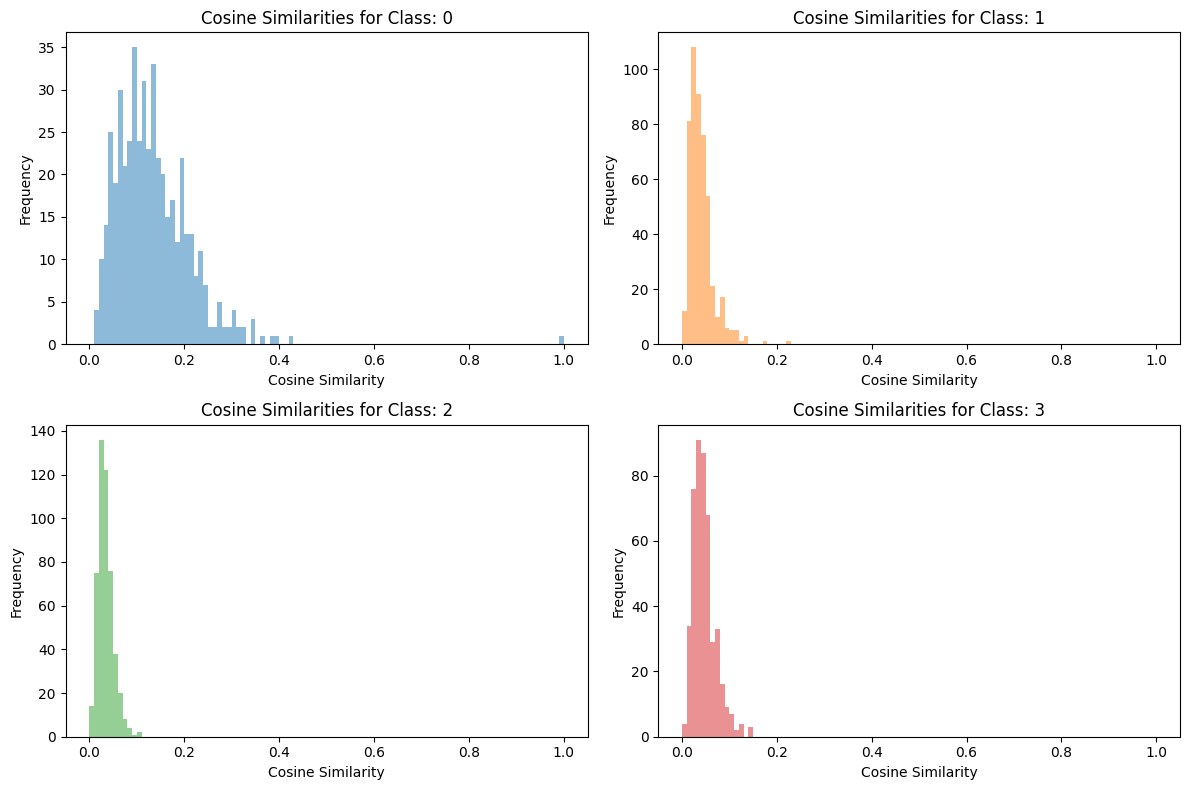

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

cosine_similarities = cosine_similarity(tfidf_embeddings_normalized[50].reshape(1, -1), tfidf_embeddings_normalized).reshape(-1)
df['similarities'] = cosine_similarities
grouped_similarities = df.groupby('clase')['similarities'].apply(list)

# Determinar el rango común del eje x
min_value = df['similarities'].min()
max_value = df['similarities'].max()
bins = 100
common_range = (min_value, max_value)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

for i, (class_name, similarities) in enumerate(grouped_similarities.items()):
    axes[i].hist(similarities, bins=bins, range=common_range, alpha=0.5, label=class_name, color=f"C{i}")
    axes[i].set_title(f'Cosine Similarities for Class: {class_name}')
    axes[i].set_xlabel('Cosine Similarity')
    axes[i].set_ylabel('Frequency')

fig.tight_layout()
plt.show()

Otro ejemplo: el artículo 600 (sobre Iván Duque y diálogos con el ELN). Debería ser muy similar a otros de política.

In [26]:
df.loc[600, 'content']

'El expresidente Iván Duque presentó su libro Duque, su presidencia este martes 22 de noviembre en la Universidad Santo Tomás, con la presencia de varios de los ministros de su gabinete y personalidades cercanas. Allí, el exmandatario se refirió a las negociaciones con el ELN que se adelantan actualmente con el gobierno de su sucesor, el presidente Gustavo Petro. Además, contó algunas intimidades de cómo ese grupo guerrillero se le acercó para tratar de llegar a una negociación. Duque aseguró que cuando llegó a la Presidencia pensaba cómo podía enfrentar a ese grupo “tan peligroso”, ya que durante varios meses habían asesinado a cientos de personas, cometían actos terroristas y continuaban secuestrando. “No podíamos abrir una compuerta donde desde el Gobierno se hablara de paz y desde ese lado se perpetrara la barbarie”, afirmó Duque. El exmandatario contó una anécdota de cómo ese grupo se le acercó para conversar. Dijo que en medio de la posesión del presidente de México, Andrés Manue

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


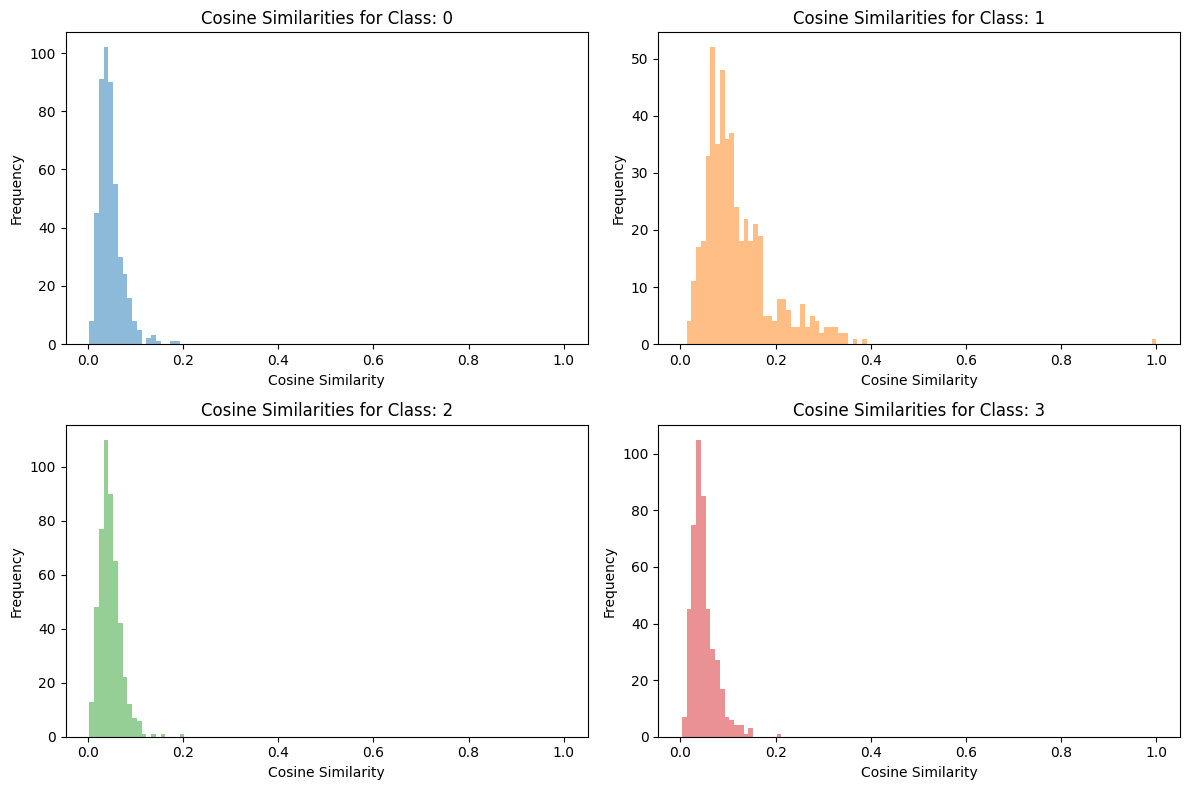

In [27]:
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

cosine_similarities = cosine_similarity(tfidf_embeddings_normalized[600].reshape(1, -1), tfidf_embeddings_normalized).reshape(-1)
df['similarities'] = cosine_similarities
grouped_similarities = df.groupby('clase')['similarities'].apply(list)

# Determinar el rango común del eje x
min_value = df['similarities'].min()
max_value = df['similarities'].max()
bins = 100
common_range = (min_value, max_value)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

for i, (class_name, similarities) in enumerate(grouped_similarities.items()):
    axes[i].hist(similarities, bins=bins, range=common_range, alpha=0.5, label=class_name, color=f"C{i}")
    axes[i].set_title(f'Cosine Similarities for Class: {class_name}')
    axes[i].set_xlabel('Cosine Similarity')
    axes[i].set_ylabel('Frequency')

fig.tight_layout()
plt.show()

### 1.8 Visualización 2D con UMAP

UMAP es una técnica de reducción de dimensionalidad no lineal. Reducimos las 2000 dimensiones de TF-IDF a 2 para ver visualmente cómo se separan los clusters.

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


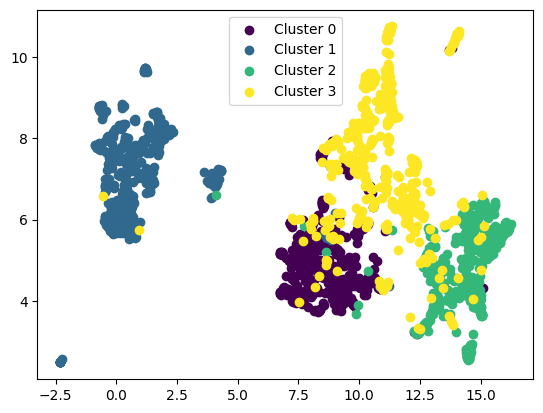

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import pandas as pd
import umap.umap_ as umap
import matplotlib.pyplot as plt

# Aplicar reducción de dimensionalidad UMAP sobre todos los puntos
umap_embeddings = umap.UMAP().fit_transform(tfidf_embeddings_normalized)

# Asignar un color a cada etiqueta de cluster
cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0, 1, num_clusters)]

# Graficar todos los puntos con colores y etiquetas distintos por cluster
for i in range(num_clusters):
    # Obtener los índices de los puntos en este cluster
    indices = kmeans.labels_ == i
    # Graficar los puntos con un color y etiqueta distintos para este cluster
    plt.scatter(umap_embeddings[indices, 0], umap_embeddings[indices, 1], c=[colors[i]], label=f'Cluster {i}')
    
# Agregar leyenda al gráfico
plt.legend()

# Mostrar el gráfico
plt.show()

### 1.9 Sub-clusters dentro de cada categoría

Si dentro de "política" hacemos KMeans con más clusters (k=10), ¿podemos descubrir sub-temas? Veamos qué encuentra dentro de cada categoría:

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import pandas as pd

df_subclusters = df_politica[['content', 'clase']].dropna()

# Entrenar el TfidfVectorizer y transformar los textos
X_tfidf = vectorizer_tfidf.fit_transform(df_subclusters['content']).toarray()
y = df['clase']

# Normalizar los embeddings TF-IDF
tfidf_embeddings_normalized = normalize(X_tfidf)

# Aplicar clustering con k-means
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=1)
kmeans.fit(tfidf_embeddings_normalized)

# Obtener feature importances y vocabulario
feature_importances = kmeans.cluster_centers_
vocabulary = vectorizer_tfidf.vocabulary_

# Imprimir las 5 features más importantes de cada cluster
print("Top n most important features of each cluster:")
for i in range(num_clusters):
    indices = np.argsort(feature_importances[i])[::-1][:10]
    features = [list(vocabulary.keys())[list(vocabulary.values()).index(index)] for index in indices]
    print("Cluster {}: {}".format(i+1, features))


Top n most important features of each cluster:
Cluster 1: ['paz', 'cese', 'eln', 'gobierno', 'paz total', 'petro', 'fuego', 'total', 'farc', 'cese fuego']
Cluster 2: ['petro', 'gobierno', 'presidente', 'ministra', 'colombia', 'país', 'gas', 'vélez', 'energía', 'ministerio']
Cluster 3: ['hernández', 'uribe', 'rodolfo hernández', 'rodolfo', 'elecciones', 'partido', 'semana', 'oposición', 'petro', 'política']
Cluster 4: ['salud', 'reforma', 'eps', 'reforma salud', 'sistema', 'corcho', 'ministra', 'sistema salud', 'gobierno', 'carolina corcho']
Cluster 5: ['metro', 'bogotá', 'línea', 'alcaldesa', 'primera línea', 'línea metro', 'lópez', 'ciudad', 'metro bogotá', 'primera']
Cluster 6: ['márquez', 'vicepresidenta', 'francia', 'francia márquez', 'cauca', 'vicepresidenta francia', 'vicepresidenta francia márquez', 'polo', 'igualdad', 'gobierno']
Cluster 7: ['presidente', 'petro', 'congreso', 'semana', 'gobierno', 'país', 'colombia', 'proyecto', 'bogotá', 'representante']
Cluster 8: ['fiscal', 

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Ahora dentro de **deportes**:

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import pandas as pd

df_subclusters = df_deportes[['content', 'clase']].dropna()

# Entrenar el TfidfVectorizer y transformar los textos
X_tfidf = vectorizer_tfidf.fit_transform(df_subclusters['content']).toarray()
y = df['clase']

# Normalizar los embeddings TF-IDF
tfidf_embeddings_normalized = normalize(X_tfidf)

# Aplicar clustering con k-means
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=1)
kmeans.fit(tfidf_embeddings_normalized)

# Obtener feature importances y vocabulario
feature_importances = kmeans.cluster_centers_
vocabulary = vectorizer_tfidf.vocabulary_

# Imprimir las 5 features más importantes de cada cluster
print("Top n most important features of each cluster:")
for i in range(num_clusters):
    indices = np.argsort(feature_importances[i])[::-1][:10]
    features = [list(vocabulary.keys())[list(vocabulary.values()).index(index)] for index in indices]
    print("Cluster {}: {}".format(i+1, features))


Top n most important features of each cluster:
Cluster 1: ['millonarios', 'junior', 'win', 'deportivo', 'estadio', 'cali', 'tolima', 'américa', 'equipo', 'betplay']
Cluster 2: ['colombia', 'selección', 'sub', 'tricolor', 'selección colombia', 'fútbol', 'femenina', 'lorenzo', 'mundial', 'sub 17']
Cluster 3: ['madrid', 'real', 'real madrid', 'ancelotti', 'benzema', 'vinicius', 'partido', 'equipo', 'carlo', 'carlo ancelotti']
Cluster 4: ['team', 'etapa', 'col', 'ineos', 'ciclista', 'vuelta', 'astana', 'lópez', 'urán', 'tour']
Cluster 5: ['mundial', 'qatar', 'argentina', 'messi', 'mundo', 'copa', 'copa mundo', 'selección', 'final', 'qatar 2022']
Cluster 6: ['james', 'olympiacos', 'james rodríguez', 'rodríguez', 'grecia', 'rayyan', 'volante', 'colombia', 'griego', 'equipo']
Cluster 7: ['liverpool', 'díaz', 'luis díaz', 'klopp', 'luis', 'premier', 'league', 'premier league', 'colombiano', 'manchester']
Cluster 8: ['barcelona', 'alves', 'millones', 'euros', 'millones euros', 'club', 'mujer', 

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Y dentro de **economía**:

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import pandas as pd

df_subclusters = df_economia[['content', 'clase']].dropna()

# Entrenar el TfidfVectorizer y transformar los textos
X_tfidf = vectorizer_tfidf.fit_transform(df_subclusters['content']).toarray()
y = df['clase']

# Normalizar los embeddings TF-IDF
tfidf_embeddings_normalized = normalize(X_tfidf)

# Aplicar clustering con k-means
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=1)
kmeans.fit(tfidf_embeddings_normalized)

# Obtener feature importances y vocabulario
feature_importances = kmeans.cluster_centers_
vocabulary = vectorizer_tfidf.vocabulary_

# Imprimir las 5 features más importantes de cada cluster
print("Top n most important features of each cluster:")
for i in range(num_clusters):
    indices = np.argsort(feature_importances[i])[::-1][:10]
    features = [list(vocabulary.keys())[list(vocabulary.values()).index(index)] for index in indices]
    print("Cluster {}: {}".format(i+1, features))


Top n most important features of each cluster:
Cluster 1: ['energía', 'gas', 'tarifas', 'eléctrica', 'energética', 'regulación', 'minas', 'energía eléctrica', 'tarifas energía', 'ministra']
Cluster 2: ['inflación', 'precios', 'tasas', 'año', 'banco', 'interés', 'salario', 'aumento', 'economía', 'salario mínimo']
Cluster 3: ['unidades', 'ecopetrol', 'bolsa', 'jornada', 'valores', 'bolsa valores', 'bolsa valores colombia', 'valores colombia', 'colcap', 'preferencial']
Cluster 4: ['vivienda', 'subsidio', 'subsidios', 'hogares', 'familias', 'viviendas', 'sector', 'casa', 'programa', 'construcción']
Cluster 5: ['pesos', 'dólar', 'centavos', 'precio', 'inflación', 'divisa', 'unidos', 'tasas', 'mercado', 'colombia']
Cluster 6: ['aerolínea', 'viva', 'air', 'avianca', 'viva air', 'pasajeros', 'aerolíneas', 'vuelos', 'aeronáutica', 'transporte']
Cluster 7: ['empresas', 'dólares', 'millones', 'clientes', 'seguridad', 'colombia', 'grupo', 'además', 'pueden', 'puede']
Cluster 8: ['reforma', 'labora

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


# Parte 2: Tokenización por subpalabras (BPE)

Hasta ahora hemos tokenizado **a nivel de palabra** con `CountVectorizer` y `TfidfVectorizer`. Cada palabra única ocupa una entrada en el vocabulario.

¿Por qué los modelos modernos (GPT, Claude, BERT, LLaMA) **no** hacen esto? Veámoslo.

## Problema 1: explosión del vocabulario

En español, cada verbo tiene decenas de conjugaciones. Para un tokenizador de palabras son **palabras completamente distintas**, aunque comparten la misma raíz.

In [32]:
verb_forms = [
    "estudio", "estudias", "estudia", "estudiamos", "estudian",
    "estudié", "estudiaste", "estudió", "estudiaron",
    "estudiaba", "estudiabas", "estudiábamos",
    "estudiaré", "estudiarás", "estudiará", "estudiaremos", "estudiarán",
    "estudiaría", "estudiarías", "estudiaríamos",
    "estudiando", "estudiado",
]

print(f"El verbo 'estudiar' tiene {len(verb_forms)} formas distintas aquí.")
print(f"Para CountVectorizer son {len(verb_forms)} entradas independientes en el vocabulario,")
print(f"aunque todas comparten la raíz 'estudi-'.\n")
print(f"Ejemplo: {verb_forms}")

El verbo 'estudiar' tiene 22 formas distintas aquí.
Para CountVectorizer son 22 entradas independientes en el vocabulario,
aunque todas comparten la raíz 'estudi-'.

Ejemplo: ['estudio', 'estudias', 'estudia', 'estudiamos', 'estudian', 'estudié', 'estudiaste', 'estudió', 'estudiaron', 'estudiaba', 'estudiabas', 'estudiábamos', 'estudiaré', 'estudiarás', 'estudiará', 'estudiaremos', 'estudiarán', 'estudiaría', 'estudiarías', 'estudiaríamos', 'estudiando', 'estudiado']


## Problema 2: palabras desconocidas (OOV)

Si entrenamos `CountVectorizer` con un corpus, cualquier palabra nueva que no estaba en ese corpus **se pierde** — el modelo no la puede representar.

In [33]:
train_texts = ["El precio del dólar subió", "La economía colombiana creció"]
vect = CountVectorizer()
vect.fit(train_texts)
print(f"Vocabulario entrenado: {list(vect.get_feature_names_out())}\n")

new_text = ["El desempleo y la devaluación preocupan"]
X_new = vect.transform(new_text)
print(f"Texto nuevo: {new_text[0]}")
print(f"Tokens reconocidos: {X_new.sum()} de {len(new_text[0].split())} palabras")
print(f"\n'desempleo', 'devaluación', 'preocupan' se PIERDEN.")
print(f"BPE las descompondría en piezas conocidas")

Vocabulario entrenado: ['colombiana', 'creció', 'del', 'dólar', 'economía', 'el', 'la', 'precio', 'subió']

Texto nuevo: El desempleo y la devaluación preocupan
Tokens reconocidos: 2 de 6 palabras

'desempleo', 'devaluación', 'preocupan' se PIERDEN.
BPE las descompondría en piezas conocidas


## El algoritmo Byte-Pair Encoding (BPE)

**Idea (Sennrich et al., 2016):** en lugar de escoger la unidad de antemano (palabra o caracter), **aprendamos** el vocabulario óptimo a partir del corpus.

1. Empezar con el vocabulario de todos los **caracteres** del corpus
2. Contar la frecuencia de cada **par adyacente** de tokens
3. Fusionar el par más frecuente en un nuevo token
4. Repetir hasta llegar al tamaño de vocabulario deseado

Resultado: las **palabras frecuentes** quedan enteras, las **raras** se descomponen en subpalabras significativas.

Veámoslo en acción usando la librería `tokenizers` de HuggingFace:

## Implementación manual paso a paso

El algoritmo es tan simple que cabe en pocas líneas de Python. Implementémoslo desde cero sobre un mini-corpus para entender qué hace por dentro:

In [34]:
from collections import Counter

# Mini-corpus de demostración
mini_corpus = [
    "la universidad abrió convocatorias",
    "la universidad nacional de colombia",
    "universidades colombianas abiertas",
    "la economía colombiana crece",
    "las universidades colombianas",
]

# Paso 0: dividir cada palabra en caracteres + marcador de fin de palabra '_'
def init_vocab(corpus):
    word_freqs = Counter()
    for text in corpus:
        for word in text.split():
            word_freqs[word] += 1
    return {tuple(list(w) + ['_']): f for w, f in word_freqs.items()}

vocab = init_vocab(mini_corpus)
print("Vocabulario inicial (cada palabra dividida en caracteres):")
for w, f in sorted(vocab.items(), key=lambda x: -x[1]):
    print(f"  {' '.join(w):45s}  freq={f}")

Vocabulario inicial (cada palabra dividida en caracteres):
  l a _                                          freq=3
  u n i v e r s i d a d _                        freq=2
  u n i v e r s i d a d e s _                    freq=2
  c o l o m b i a n a s _                        freq=2
  a b r i ó _                                    freq=1
  c o n v o c a t o r i a s _                    freq=1
  n a c i o n a l _                              freq=1
  d e _                                          freq=1
  c o l o m b i a _                              freq=1
  a b i e r t a s _                              freq=1
  e c o n o m í a _                              freq=1
  c o l o m b i a n a _                          freq=1
  c r e c e _                                    freq=1
  l a s _                                        freq=1


In [35]:
# Pasos 1 y 2: contar pares adyacentes y fusionar el más frecuente
def count_pairs(vocab):
    pairs = Counter()
    for word, freq in vocab.items():
        for i in range(len(word) - 1):
            pairs[(word[i], word[i+1])] += freq
    return pairs

def merge_pair(vocab, pair):
    new_token = pair[0] + pair[1]
    new_vocab = {}
    for word, freq in vocab.items():
        new_word, i = [], 0
        while i < len(word):
            if i < len(word) - 1 and (word[i], word[i+1]) == pair:
                new_word.append(new_token)
                i += 2
            else:
                new_word.append(word[i])
                i += 1
        new_vocab[tuple(new_word)] = freq
    return new_vocab

# Veamos los 5 pares más frecuentes en este momento
pairs = count_pairs(vocab)
print("Top 5 pares adyacentes:")
for pair, freq in pairs.most_common(5):
    print(f"  '{pair[0]}' + '{pair[1]}' → '{pair[0]+pair[1]}'   (freq={freq})")

Top 5 pares adyacentes:
  's' + '_' → 's_'   (freq=7)
  'a' + '_' → 'a_'   (freq=6)
  'c' + 'o' → 'co'   (freq=6)
  'e' + 'r' → 'er'   (freq=5)
  'i' + 'a' → 'ia'   (freq=5)


In [36]:
# Paso 3: repetir N veces — cada iteración crea un token nuevo
vocab = init_vocab(mini_corpus)
merge_rules = []
NUM_MERGES = 15

print(f"Ejecutando {NUM_MERGES} fusiones:\n")
for step in range(NUM_MERGES):
    pairs = count_pairs(vocab)
    if not pairs:
        break
    best_pair, freq = pairs.most_common(1)[0]
    merge_rules.append(best_pair)
    vocab = merge_pair(vocab, best_pair)
    print(f"  Fusión {step+1:>2}: '{best_pair[0]}' + '{best_pair[1]}' → '{best_pair[0]+best_pair[1]}' (freq={freq})")

print("\nVocabulario final del corpus:")
for w, f in sorted(vocab.items(), key=lambda x: -x[1]):
    print(f"  {' '.join(w):45s}  freq={f}")

Ejecutando 15 fusiones:

  Fusión  1: 's' + '_' → 's_' (freq=7)
  Fusión  2: 'a' + '_' → 'a_' (freq=6)
  Fusión  3: 'c' + 'o' → 'co' (freq=6)
  Fusión  4: 'e' + 'r' → 'er' (freq=5)
  Fusión  5: 'a' + 's_' → 'as_' (freq=5)
  Fusión  6: 'o' + 'm' → 'om' (freq=5)
  Fusión  7: 'b' + 'i' → 'bi' (freq=5)
  Fusión  8: 'u' + 'n' → 'un' (freq=4)
  Fusión  9: 'un' + 'i' → 'uni' (freq=4)
  Fusión 10: 'uni' + 'v' → 'univ' (freq=4)
  Fusión 11: 'univ' + 'er' → 'univer' (freq=4)
  Fusión 12: 'univer' + 's' → 'univers' (freq=4)
  Fusión 13: 'univers' + 'i' → 'universi' (freq=4)
  Fusión 14: 'universi' + 'd' → 'universid' (freq=4)
  Fusión 15: 'universid' + 'a' → 'universida' (freq=4)

Vocabulario final del corpus:
  l a_                                           freq=3
  universida d _                                 freq=2
  universida d e s_                              freq=2
  co l om bi a n as_                             freq=2
  a b r i ó _                                    freq=1
  co n v o 

In [37]:
# Tokenizar palabras NUEVAS aplicando las reglas de fusión aprendidas, en orden
def tokenize(word, merge_rules):
    tokens = list(word) + ['_']
    for pair in merge_rules:
        new_tokens, i = [], 0
        while i < len(tokens):
            if i < len(tokens) - 1 and (tokens[i], tokens[i+1]) == pair:
                new_tokens.append(tokens[i] + tokens[i+1])
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        tokens = new_tokens
    return tokens

# Probemos con palabras del corpus y palabras NUEVAS
test_words = ["universidad", "colombiana", "universitarias", "ecosistema"]
for w in test_words:
    print(f"  {w:18s} → {tokenize(w, merge_rules)}")

print("\nNote cómo 'universitarias' (que NO está en el corpus) se descompone")
print("en piezas conocidas como 'universidad' y restos de caracteres.")
print("Esa es la magia de BPE: maneja palabras nuevas sin perderlas.")

  universidad        → ['universida', 'd', '_']
  colombiana         → ['co', 'l', 'om', 'bi', 'a', 'n', 'a_']
  universitarias     → ['universi', 't', 'a', 'r', 'i', 'as_']
  ecosistema         → ['e', 'co', 's', 'i', 's', 't', 'e', 'm', 'a_']

Note cómo 'universitarias' (que NO está en el corpus) se descompone
en piezas conocidas como 'universidad' y restos de caracteres.
Esa es la magia de BPE: maneja palabras nuevas sin perderlas.


### En la práctica: HuggingFace

El algoritmo es el mismo, pero la implementación de [`tokenizers`](https://github.com/huggingface/tokenizers) está escrita en Rust y entrena en segundos sobre corpus enormes:

In [38]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# Reusamos las noticias cargadas arriba (df con columnas 'content' y 'clase')
texts = df['content'].dropna().tolist()
print(f"Corpus de entrenamiento: {len(texts)} artículos de noticias")

# Crear y entrenar tokenizador BPE
tokenizer_bpe = Tokenizer(models.BPE())
tokenizer_bpe.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)

trainer = trainers.BpeTrainer(
    vocab_size=5000,
    min_frequency=2,
    special_tokens=["<pad>", "<unk>", "<s>", "</s>"]
)

tokenizer_bpe.train_from_iterator(texts, trainer=trainer)

print(f"\nTokenizador BPE entrenado.")
print(f"Tamaño de vocabulario: {tokenizer_bpe.get_vocab_size():,}")

Corpus de entrenamiento: 1933 artículos de noticias




Tokenizador BPE entrenado.
Tamaño de vocabulario: 5,000


In [39]:
# Probemos el tokenizador en oraciones reales
test_sentences = [
    "La universidad Nacional abrió convocatorias para becas internacionales.",
    "La selección colombiana ganó el partido contra Argentina.",
    "El Banco de la República mantuvo las tasas de interés en 12.75%.",
]

for sent in test_sentences:
    encoded = tokenizer_bpe.encode(sent)
    print(f"\n  Texto:  {sent}")
    print(f"  Tokens: {encoded.tokens}")
    print(f"  Total:  {len(encoded.tokens)} tokens")


  Texto:  La universidad Nacional abrió convocatorias para becas internacionales.
  Tokens: ['La', 'Ġuniversidad', 'ĠNacional', 'ĠabriÃ³', 'Ġconvoca', 'torias', 'Ġpara', 'Ġbecas', 'Ġinternacionales', '.']
  Total:  10 tokens

  Texto:  La selección colombiana ganó el partido contra Argentina.
  Tokens: ['La', 'ĠselecciÃ³n', 'Ġcolombiana', 'ĠganÃ³', 'Ġel', 'Ġpartido', 'Ġcontra', 'ĠArgentina', '.']
  Total:  9 tokens

  Texto:  El Banco de la República mantuvo las tasas de interés en 12.75%.
  Tokens: ['El', 'ĠBanco', 'Ġde', 'Ġla', 'ĠRepÃºblica', 'Ġman', 'tuvo', 'Ġlas', 'Ġtasas', 'Ġde', 'ĠinterÃ©s', 'Ġen', 'Ġ12', '.', '7', '5', '%', '.']
  Total:  18 tokens


In [40]:
# BPE puede manejar palabras raras y desconocidas: las descompone en subpalabras conocidas
rare_words = [
    "desfinanciarización",   # término financiero raro
    "electroencefalograma",  # término médico
    "criptomonedas",         # término relativamente nuevo
    "Barranquilla",          # nombre propio
    "desafortunadamente",    # palabra larga compuesta
]

print("Tokenización BPE de palabras raras:\n")
for word in rare_words:
    tokens = tokenizer_bpe.encode(word).tokens
    print(f"  {word:25s} → {tokens}")

print("\nCon CountVectorizer todas estas serían [DESCONOCIDO].")
print("Con BPE el modelo aún puede extraer significado de las piezas.")

Tokenización BPE de palabras raras:

  desfinanciarización       → ['des', 'fin', 'anci', 'ari', 'z', 'aciÃ³n']
  electroencefalograma      → ['el', 'ec', 'tro', 'en', 'ce', 'f', 'alo', 'grama']
  criptomonedas             → ['cri', 'p', 'tom', 'one', 'das']
  Barranquilla              → ['B', 'ar', 'ranquilla']
  desafortunadamente        → ['des', 'a', 'f', 'ort', 'un', 'adamente']

Con CountVectorizer todas estas serían [DESCONOCIDO].
Con BPE el modelo aún puede extraer significado de las piezas.


## Comparación con tokenizadores reales: GPT-2 y BERT

Los modelos modernos vienen con su propio tokenizador BPE/WordPiece pre-entrenado. Veamos cómo manejan español:

In [41]:
from transformers import AutoTokenizer

gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
bert_tok = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")

text = "La inflación en Colombia alcanzó niveles preocupantes durante el último trimestre."

print(f"Texto: \"{text}\"\n")
print(f"GPT-2 (BPE entrenado en inglés) — {len(gpt2_tok.tokenize(text))} tokens:")
print(f"  {gpt2_tok.tokenize(text)}\n")
print(f"BERT multilingüe (WordPiece, 100+ idiomas) — {len(bert_tok.tokenize(text))} tokens:")
print(f"  {bert_tok.tokenize(text)}\n")
print(f"Nuestro BPE entrenado en noticias — {len(tokenizer_bpe.encode(text).tokens)} tokens:")
print(f"  {tokenizer_bpe.encode(text).tokens}")

Texto: "La inflación en Colombia alcanzó niveles preocupantes durante el último trimestre."

GPT-2 (BPE entrenado en inglés) — 28 tokens:
  ['La', 'Ġinfl', 'aci', 'Ã³n', 'Ġen', 'ĠColombia', 'Ġal', 'can', 'z', 'Ã³', 'Ġn', 'ive', 'les', 'Ġpre', 'oc', 'up', 'antes', 'Ġdur', 'ante', 'Ġel', 'ĠÃ', 'º', 'lt', 'imo', 'Ġtrim', 'est', 're', '.']

BERT multilingüe (WordPiece, 100+ idiomas) — 18 tokens:
  ['La', 'in', '##f', '##lación', 'en', 'Colombia', 'alcanzó', 'niveles', 'pre', '##oc', '##upan', '##tes', 'durante', 'el', 'último', 'trim', '##estre', '.']

Nuestro BPE entrenado en noticias — 13 tokens:
  ['La', 'ĠinflaciÃ³n', 'Ġen', 'ĠColombia', 'ĠalcanzÃ³', 'Ġniveles', 'Ġpreocup', 'antes', 'Ġdurante', 'Ġel', 'ĠÃºltimo', 'Ġtrimestre', '.']


## ¿Mejora la clasificación con BPE?

Recordemos que arriba entrenamos un **XGBoost con features TF-IDF de palabras** y obtuvimos:

| Clase | Precision | Recall | F1 |
|---|---|---|---|
| 0 (Educación) | 0.92 | 0.91 | 0.91 |
| 1 (Política)  | 0.88 | 0.91 | 0.90 |
| 2 (Deportes)  | 0.98 | 1.00 | 0.99 |
| 3 (Economía)  | 0.85 | 0.81 | 0.83 |

¿Qué pasa si en lugar de tokenizar por palabras, tokenizamos con BPE? La gracia: BPE captura raíces compartidas (ej. `universidad` y `universidades` comparten subpalabras), lo cual podría dar un vocabulario más denso de información.

In [42]:
# Re-tokenizar todos los artículos con nuestro tokenizador BPE
# y construir features TF-IDF sobre los tokens BPE
def bpe_tokenize_to_string(text):
    return ' '.join(tokenizer_bpe.encode(text).tokens)

print("Tokenizando los 1933 artículos con BPE...")
df_bpe_tokens = df['content'].apply(bpe_tokenize_to_string)

# TF-IDF sobre tokens BPE (mismo presupuesto de 2000 features que antes)
# token_pattern=r'\S+' para que el vectorizador no vuelva a partir los tokens BPE (que ya incluyen 'Ġ' y demás)
vectorizer_bpe_tfidf = TfidfVectorizer(
    max_features=2000,
    lowercase=False,
    token_pattern=r'\S+',
    ngram_range=(1, 3),
)
X_bpe = vectorizer_bpe_tfidf.fit_transform(df_bpe_tokens).toarray()
print(f"Shape de features BPE: {X_bpe.shape}")
print(f"Ejemplo de features (primeros 15):")
print(f"  {list(vectorizer_bpe_tfidf.get_feature_names_out()[:15])}")

Tokenizando los 1933 artículos con BPE...


Shape de features BPE: (1933, 2000)
Ejemplo de features (primeros 15):
  ['%', ')', ') Ġy', '),', ').', ',', ', 3', ', 4', ', 5', ', 6', ', 7', ', Ġa', ', ĠademÃ¡s', ', Ġal', ', ĠasÃŃ']


In [43]:
# Entrenar XGBoost EXACTAMENTE igual que antes, pero con features BPE
X_train, X_test, y_train, y_test = train_test_split(X_bpe, y, test_size=0.2, random_state=1)

model_bpe = xgb.XGBClassifier()
model_bpe.fit(X_train, y_train)
y_pred = model_bpe.predict(X_test)

print("Resultados con features BPE:\n")
class_names = ['Educación', 'Política ', 'Deportes ', 'Economía ']
for i in range(len(set(y_test))):
    cp = [1 if x == i else 0 for x in y_pred]
    cr = [1 if x == i else 0 for x in y_test]
    p = precision_score(cr, cp); r = recall_score(cr, cp); f1 = f1_score(cr, cp)
    print(f"  Clase {i} ({class_names[i]}): P={p:.2f}  R={r:.2f}  F1={f1:.2f}")

# Tokens más importantes (ahora son subpalabras BPE, no palabras enteras)
fi = model_bpe.feature_importances_
vocab_bpe = vectorizer_bpe_tfidf.get_feature_names_out()
print("\nTop 10 tokens BPE más importantes para la clasificación:")
for idx in fi.argsort()[::-1][:10]:
    print(f"  {vocab_bpe[idx]:<30s}  {fi[idx]*100:.2f}%")

Resultados con features BPE:

  Clase 0 (Educación): P=0.93  R=0.95  F1=0.94
  Clase 1 (Política ): P=0.87  R=0.91  F1=0.89
  Clase 2 (Deportes ): P=0.98  R=0.98  F1=0.98
  Clase 3 (Economía ): P=0.89  R=0.82  F1=0.85

Top 10 tokens BPE más importantes para la clasificación:
  ĠinflaciÃ³n                     4.37%
  ĠfÃºtbol                        2.96%
  Ġestudiantes                    2.90%
  ĠHistÃ³rico                     2.53%
  Ġcongresistas                   2.37%
  ĠGustavo ĠPetro                 1.56%
  Ġequipo                         1.50%
  ĠCopa                           1.39%
  ĠformaciÃ³n                     1.36%
  ĠPetro                          1.28%


**Observaciones:**
- En este caso obtuvimos un desempeño **muy similar** al de TF-IDF de palabras (incluso un poco mejor en algunas clases). Esto es esperable: las 4 categorías son tan distintas que las palabras enteras ya son señales suficientes
- **¿Para qué sirve BPE entonces?** No tanto para mejorar XGBoost en clasificación temática, sino porque es el formato de entrada que requieren GPT, BERT y demás modelos neuronales. Allí brilla: maneja vocabulario abierto, comparte representaciones entre formas relacionadas (ej. *universidad / universidades*), y permite escalar a cualquier idioma sin cambiar el tokenizador

# Parte 3: Embeddings — representaciones densas con significado

Hasta aquí todas nuestras representaciones (CountVectorizer, TF-IDF) son **vectores dispersos** (sparse): de los 2000 tokens del vocabulario, casi todos son cero para cualquier documento.

**Limitación clave**: estos vectores no capturan **significado**. Para TF-IDF, "presidente" y "mandatario" son tan distintos como "presidente" y "fútbol" — son dimensiones ortogonales.

**Idea de los embeddings**: representar cada palabra (o documento) como un vector **denso** de pocas dimensiones (~300-768) donde palabras semánticamente similares quedan **cerca** en el espacio.

¿De dónde salen estos vectores? **De redes neuronales entrenadas con miles de millones de oraciones**. La próxima clase veremos cómo se entrenan. Por ahora, usemos uno pre-entrenado para ver la magia.

In [44]:
from sentence_transformers import SentenceTransformer

# Modelo multilingüe pequeño (~120 MB), funciona muy bien en español
embed_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
print(f"Dimensión de los embeddings: {embed_model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9787.59it/s]


BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dimensión de los embeddings: 384


/var/folders/xv/3kf2bm9n0937_dwd7rxxtf3c0000gn/T/ipykernel_15982/2556378233.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Dimensión de los embeddings: {embed_model.get_sentence_embedding_dimension()}")


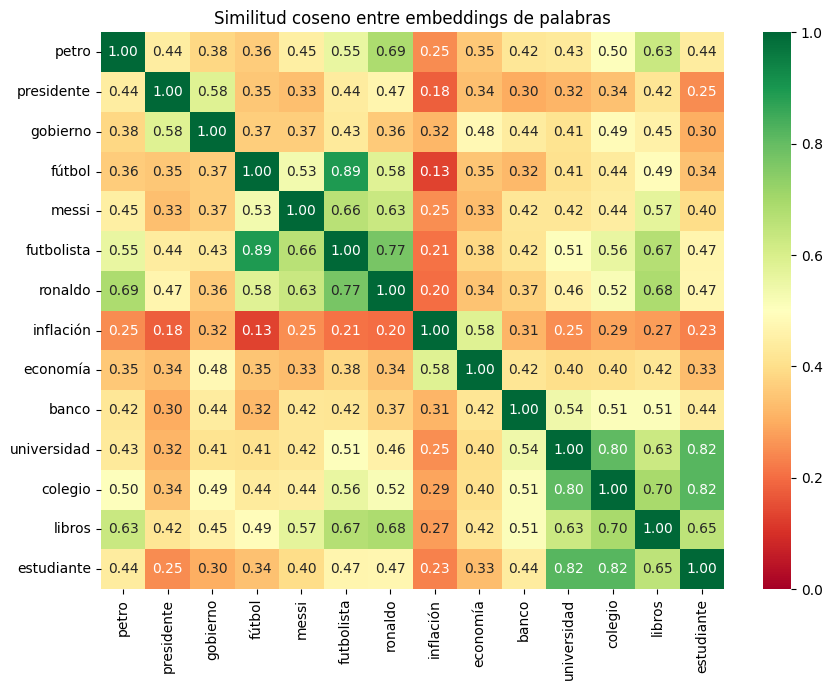


Observe cómo el modelo agrupa semánticamente:
  - 'petro', 'presidente', 'gobierno' → política
  - 'fútbol', 'messi', 'futbolista' → deportes
  - 'inflación', 'economía' → economía
  - 'universidad', 'estudiante' → educación

TF-IDF NO podría hacer esto: trata cada palabra como dimensión independiente.


In [45]:
# Embeddings de palabras: matriz de similitud
words = ['petro', 'presidente', 'gobierno', 'fútbol', 'messi', 'futbolista', 'ronaldo',
         'inflación', 'economía', 'banco', 'universidad', 'colegio', 'libros', 'estudiante']

word_embs = embed_model.encode(words)
sim_matrix = cosine_similarity(word_embs)

import seaborn as sns
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0.5, vmin=0, vmax=1, ax=ax)
ax.set_title('Similitud coseno entre embeddings de palabras')
plt.tight_layout()
plt.show()

print("\nObserve cómo el modelo agrupa semánticamente:")
print("  - 'petro', 'presidente', 'gobierno' → política")
print("  - 'fútbol', 'messi', 'futbolista' → deportes")
print("  - 'inflación', 'economía' → economía")
print("  - 'universidad', 'estudiante' → educación")
print("\nTF-IDF NO podría hacer esto: trata cada palabra como dimensión independiente.")

## Embeddings aplicados a documentos

Calculemos embeddings de los 1933 artículos de noticias y comparemos con lo que hicimos con TF-IDF.

In [46]:
# Reconstruir el df completo de las 4 categorías (por si se sobrescribió arriba)
df_educacion = pd.read_csv("../datasets/noticias_educacion_sample.csv"); df_educacion['clase'] = 0
df_politica = pd.read_csv("../datasets/noticias_politica_sample.csv");   df_politica['clase']  = 1
df_deportes = pd.read_csv("../datasets/noticias_deportes_sample.csv");   df_deportes['clase']  = 2
df_economia = pd.read_csv("../datasets/noticias_economia_sample.csv");   df_economia['clase']  = 3
df_full = pd.concat([df_educacion, df_politica, df_deportes, df_economia]).dropna().reset_index(drop=True)

# Los artículos largos se truncan (el modelo tiene límite de 128 tokens; nos importa el inicio)
print(f"Calculando embeddings de {len(df_full)} artículos...")
doc_embeddings = embed_model.encode(
    df_full['content'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"\nShape: {doc_embeddings.shape}  (1 fila por artículo, 384 dims)")

Calculando embeddings de 1933 artículos...


Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   2%|▏         | 1/61 [00:00<00:11,  5.09it/s]

Batches:   3%|▎         | 2/61 [00:00<00:08,  6.67it/s]

Batches:   5%|▍         | 3/61 [00:00<00:07,  7.56it/s]

...

Batches:  92%|█████████▏| 56/61 [00:05<00:00,  9.88it/s]

Batches:  95%|█████████▌| 58/61 [00:06<00:00,  9.97it/s]

Batches:  98%|█████████▊| 60/61 [00:06<00:00, 10.06it/s]

Batches: 100%|██████████| 61/61 [00:06<00:00,  9.50it/s]


Shape: (1933, 384)  (1 fila por artículo, 384 dims)


In [47]:
# Clustering con KMeans sobre los embeddings densos
from sklearn.preprocessing import normalize

doc_embs_norm = normalize(doc_embeddings)

kmeans_dense = KMeans(n_clusters=4, random_state=1, n_init=10)
kmeans_dense.fit(doc_embs_norm)

print(f"KMeans entrenado: {kmeans_dense.n_clusters} clusters sobre {doc_embs_norm.shape[0]} documentos")

KMeans entrenado: 4 clusters sobre 1933 documentos


/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/p

/Users/davidzarruk/Documents/MIAD_ML_NLP_2026/.env/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


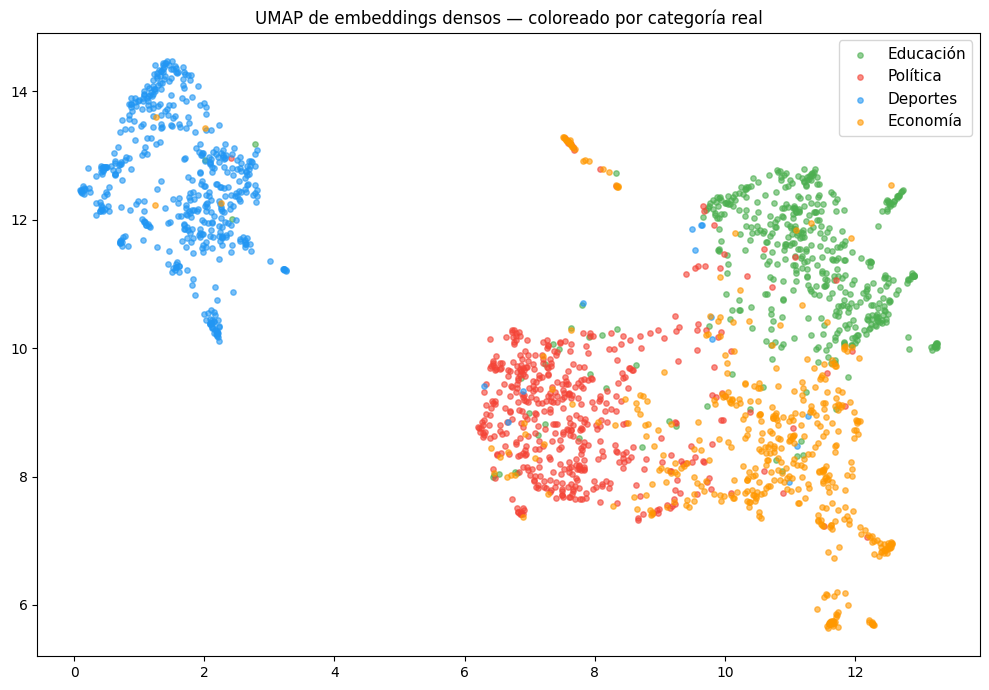

Las 4 categorías quedan claramente separadas en el espacio de embeddings,
aunque el modelo NUNCA fue entrenado en estas categorías.
Solo aprendió 'qué textos significan cosas parecidas' a partir de mucho texto.


In [48]:
# Visualización con UMAP: ¿se separan visualmente las clases?
umap_embs = umap.UMAP(random_state=1).fit_transform(doc_embs_norm)

class_names = {0: 'Educación', 1: 'Política', 2: 'Deportes', 3: 'Economía'}
colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800']

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(4):
    mask = df_full['clase'] == c
    ax.scatter(umap_embs[mask, 0], umap_embs[mask, 1],
               c=colors[c], label=class_names[c], alpha=0.6, s=15)
ax.legend(fontsize=11)
ax.set_title('UMAP de embeddings densos — coloreado por categoría real')
plt.tight_layout()
plt.show()

print("Las 4 categorías quedan claramente separadas en el espacio de embeddings,")
print("aunque el modelo NUNCA fue entrenado en estas categorías.")
print("Solo aprendió 'qué textos significan cosas parecidas' a partir de mucho texto.")

## Resumen y puente a la próxima clase

| Representación | Tipo | Captura significado | Usado por |
|---|---|---|---|
| **CountVectorizer** | sparse, ~vocab dims | No | NLP clásico |
| **TF-IDF** | sparse, ~vocab dims | No (pondera importancia, no significado) | NLP clásico |
| **BPE / WordPiece** | tokenización (no es vector) | — (es solo cómo dividir texto) | GPT, BERT, Claude |
| **Embeddings densos** | dense, 100-1024 dims | **Sí** | Word2Vec, GloVe, Sentence Transformers |

### ¿Y cómo se entrenan estos embeddings?

Los embeddings que acabamos de usar los produce una **red neuronal** (un transformer pequeño en este caso) entrenada con miles de millones de oraciones. La red aprende a producir vectores tales que:
- Textos con significado parecido → vectores parecidos
- Textos con significado distinto → vectores lejanos

**La próxima clase entramos a redes neuronales**: empezaremos con perceptrones multicapa, veremos cómo aprenden a partir de datos, y construiremos la base para entender Word2Vec, BERT y los LLMs modernos.